# FNCE 449 Day 1 (Part B): Linear Factor Models for Stock Prices

In this lecture, we aim to explain the cross-section of equity returns ($R_{it}$) using a linear risk factor structure model, where $F_1, F_2,\dots F_k$ are factors such as the market return, momentum, liqudity, or the Fama-French factors. 

$$R_{it}=\alpha_i + \beta_{1i} F_{1t} + \beta_{2i} F_{2t} + \dots + \beta_{ki} F_{kt} + \epsilon_{it}$$

The purpose of the factor models for asset returns is both:
1. to estimate risk exposure of a given security $i$ to a factor $F_k$ (i.e., the $\beta_{ki}$)
2. to identify any excess return, or $\alpha$ for the security that cannot be accounted for by the risk factors considered.

## Preliminaries: Understanding the data

First off, we load stock price data from CRSP (Center for Research in Security Prices) and visualize it.

In [2]:
# Import necessary libraries
import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt  # For data visualization
import warnings  # To handle warnings

# Ignore any warning messages
warnings.filterwarnings('ignore')

# URL of the data file
url = "https://github.com/mariuszoican/fnce449/blob/main/Data/CRSP_Data.xlsx?raw=true"

# Load the data from the Excel file into a DataFrame
# The 'index_col=0' argument sets the first column as the index
crsp = pd.read_excel(url, index_col=0)

# Display the first few rows of the dataset to get an overview
crsp.head()

,PERMNO,date,TICKER,PRC,mktrf,smb,hml,rf,umd
0,10001,20090831,EGAS,8.5400,0.0333,-0.0090,0.0776,0.0001,-0.0884
1,10001,20090930,EGAS,8.5999,0.0408,0.0245,0.0092,0.0001,-0.0493
2,10001,20091030,EGAS,8.8800,-0.0259,-0.0423,-0.0418,0.0000,0.0265
3,10001,20091130,EGAS,8.8980,0.0556,-0.0249,-0.0017,0.0000,0.0029
4,10001,20091231,EGAS,10.3000,0.0275,0.0611,0.0001,0.0001,0.0291


In [3]:
# Display the earliest and latest dates in the dataset
# This helps to understand the time range covered by the data
crsp.date.min(), crsp.date.max()

(np.int64(20070131), np.int64(20181231))

In [4]:
# Count the number of unique ticker symbols in the dataset
# This gives us an idea of how many different stocks are represented in the data
crsp['TICKER'].nunique()

1619

The structure of the data is as follows:

**Data description**

1. **PERMNO** = CRSP Permanent Company Number
2. **date** = in format YYYYMMDD
3. **TICKER** = trading ticker for the stock
4. **PRC** = end-of-month price
5. **mktrf** = market return minus risk free rate
6. **smb** = small minus big factor (Fama-French "size" factor)
7. **hml** = high minus low book-to-market factor (Fama-French "value" factor)
8. **rf** = risk-free rate
9. **umd** = up minus down momentum factor

In [5]:
# How many stocks are in the dataset?
len(crsp['TICKER'].drop_duplicates().to_list())

1619

In [6]:
# Convert date from integers to Pandas date format
crsp['date'] = pd.to_datetime(crsp['date'], format='%Y%m%d')
crsp.head(2)

,PERMNO,date,TICKER,PRC,mktrf,smb,hml,rf,umd
0,10001,2009-08-31,EGAS,8.5400,0.0333,-0.0090,0.0776,0.0001,-0.0884
1,10001,2009-09-30,EGAS,8.5999,0.0408,0.0245,0.0092,0.0001,-0.0493


In [7]:
crsp['date'].head()

0   2009-08-31
1   2009-09-30
2   2009-10-30
3   2009-11-30
4   2009-12-31
Name: date, dtype: datetime64[us]

We compute stock returns, as the original data only includes prices.

In [8]:
# we compute returns as percent change from previous period
crsp["RET"] = crsp.groupby('TICKER')['PRC'].transform(lambda x: x.pct_change(1))
crsp.head(10)

,PERMNO,date,TICKER,PRC,mktrf,smb,hml,rf,umd,RET
0,10001,2009-08-31,EGAS,8.5400,0.0333,-0.0090,0.0776,0.0001,-0.0884,NaN
1,10001,2009-09-30,EGAS,8.5999,0.0408,0.0245,0.0092,0.0001,-0.0493,0.007014
2,10001,2009-10-30,EGAS,8.8800,-0.0259,-0.0423,-0.0418,0.0000,0.0265,0.032570
3,10001,2009-11-30,EGAS,8.8980,0.0556,-0.0249,-0.0017,0.0000,0.0029,0.002027
4,10001,2009-12-31,EGAS,10.3000,0.0275,0.0611,0.0001,0.0001,0.0291,0.157563
5,10001,2010-01-29,EGAS,10.0600,-0.0336,0.0038,0.0031,0.0000,-0.0538,-0.023301
6,10001,2010-02-26,EGAS,10.0084,0.0340,0.0121,0.0317,0.0000,0.0360,-0.005129
7,10001,2010-03-31,EGAS,10.1700,0.0631,0.0143,0.0210,0.0001,0.0366,0.016146
8,10001,2010-04-30,EGAS,11.3900,0.0200,0.0498,0.0281,0.0001,0.0322,0.119961
9,10001,2010-05-28,EGAS,11.4000,-0.0789,0.0005,-0.0238,0.0001,-0.0013,0.000878


Let us focus on a few stocks in the sample (Apple, Oracle, NVidia, Amazon, EBay):

In [9]:
# Selecting specific stocks from the dataset
# Define a list of ticker symbols we are interested in
lstocks = ['AAPL', 'ORCL', 'NVDA', 'AMZN', 'EBAY']

# Filter the dataset to include only the rows where the 'TICKER' column matches one of the ticker symbols in the list
# The isin() function is used to check if each value in 'TICKER' is in the lstocks list
df = crsp[crsp['TICKER'].isin(lstocks)]

# Display the first 5 rows of the filtered dataset to verify the selection
df.head(5)

,PERMNO,date,TICKER,PRC,mktrf,smb,hml,rf,umd,RET
134,10104,2007-01-31,ORCL,17.16,0.0140,0.0010,-0.0011,0.0044,0.0021,NaN
135,10104,2007-02-28,ORCL,16.43,-0.0196,0.0132,-0.0009,0.0038,-0.0135,-0.042541
136,10104,2007-03-30,ORCL,18.13,0.0068,-0.0006,-0.0022,0.0043,0.0247,0.103469
137,10104,2007-04-30,ORCL,18.80,0.0349,-0.0206,-0.0115,0.0044,-0.0016,0.036955
138,10104,2007-05-31,ORCL,19.38,0.0324,0.0003,-0.0005,0.0041,-0.0026,0.030851


For each stock, we have 144 observations (monthly prices for 12 years: 12 x 12 =144).

In [10]:
df.groupby('TICKER').count()

,PERMNO,date,PRC,mktrf,smb,hml,rf,umd,RET
TICKER,,,,,,,,,
AAPL,144,144,144,144,144,144,144,144,143
AMZN,144,144,144,144,144,144,144,144,143
EBAY,144,144,144,144,144,144,144,144,143
NVDA,144,144,144,144,144,144,144,144,143
ORCL,144,144,144,144,144,144,144,144,143


We provide the summary statistics of the returns (mean, std, min, max) and the 10th, 25th, 50th, 75th, 90th percentiles of the 5 stock returns.

In [11]:
# Pivot the DataFrame to reformat it
# The pivot() function reshapes the DataFrame so that each unique value in 'TICKER' becomes a column,
# the 'date' column becomes the index, and the values in the 'RET' column are placed in the corresponding cells.
df2 = df.pivot(columns='TICKER', values='RET', index='date')

# Display the first 5 rows of the pivoted DataFrame to verify the new format
df2.head()

TICKER,AAPL,AMZN,EBAY,NVDA,ORCL
date,,,,,
2007-01-31,NaN,NaN,NaN,NaN,NaN
2007-02-28,-0.013064,0.039023,-0.010188,0.011419,-0.042541
2007-03-30,0.098097,0.016607,0.033999,-0.071613,0.103469
2007-04-30,0.074158,0.541342,0.023831,0.142808,0.036955
2007-05-31,0.214339,0.127344,-0.040660,0.053177,0.030851


In [12]:
# Generate summary statistics for the pivoted DataFrame
# The describe() function provides summary statistics for each column (each stock's returns),
# including count, mean, standard deviation, minimum, and maximum values.
# The percentiles argument specifies which percentiles to include in the output.
stat = df2.describe(percentiles=[.1, .25, .5, .75, .9])

# Display the summary statistics
stat

TICKER,AAPL,AMZN,EBAY,NVDA,ORCL
count,143.000000,143.000000,143.000000,143.000000,143.000000
mean,0.016075,0.031020,0.004361,0.019546,0.008914
std,0.116410,0.102091,0.098519,0.136956,0.065732
min,-0.853191,-0.254018,-0.533201,-0.388889,-0.181818
10%,-0.086671,-0.084772,-0.088257,-0.154994,-0.076505
25%,-0.026284,-0.032091,-0.044829,-0.050297,-0.038811
50%,0.019953,0.026226,0.000000,0.025728,0.010892
75%,0.075403,0.083982,0.058379,0.094252,0.047721
90%,0.128549,0.144888,0.104477,0.157530,0.094065
max,0.237701,0.541342,0.331055,0.553247,0.229114


## Visualizing Data: The `matplotlib` Library

The `matplotlib` library is widely used for creating static, animated, and interactive visualizations in Python. Below are some useful functions and methods for plotting:

1. **Plot function**: `plt.plot(x, y, options)`
   - Plots data points `x` and `y` with specified options.
2. **Add a grid**: `plt.grid()`
   - Adds a grid to the plot for better readability.
3. **Custom axis limits**: `plt.xlim(xmin, xmax)`
   - Sets the limits of the x-axis from `xmin` to `xmax`.
4. "**Tight" axes:** `plt.axis('tight')`
   - Adjusts the plot limits to fit the data tightly.
5. **Axes labels**: `plt.xlabel(label), plt.ylabel(label)`
   - Labels the x-axis and y-axis with specified `label`.
6. **Add a title**: `plt.title(title)`
   - Adds a title to the plot.
7. **Show the plot**: `plt.show()`
   - Displays the plot.
8. **Save the plot**: `plt.savefig(path)`
   - Saves the plot to the specified file path.

### Plot Options

| Plot Option   | Python Syntax |   
|---------------|---------------|
| Color         | c= or color=  | 
| Line width    | lw= or linewidth= |
| Line style    | ls= or linestyle= |

### Colors and Styles

| Color | Description | Style | Description |
|-------|-------------|-------|-------------|
| **b** | blue        | **-** | solid       |
| **g** | green       | **--** | dashed     |
| **r** | red         | **-.** | dash-dot   |
| **k** | black       | **:** | dotted     |
| **c** | cyan        | **.** | point marker |
| **m** | magenta     | **o, <, >, +** | other markers |

We import the `matlotlib` library for data visualization.


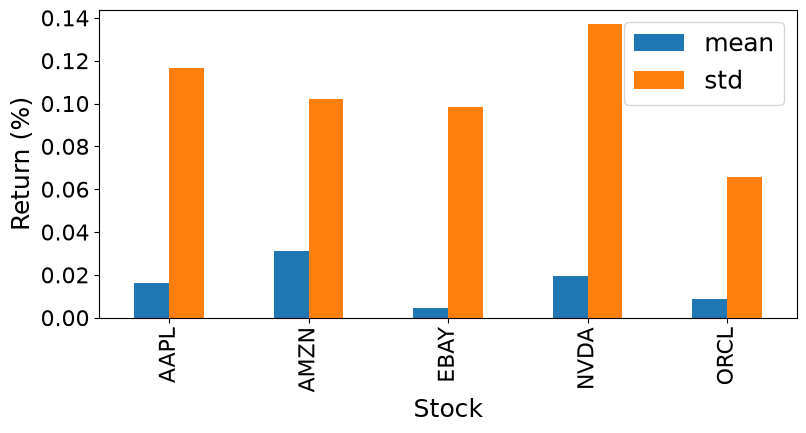

In [13]:
# Import the matplotlib library for data visualization
import matplotlib.pyplot as plt

# Transpose the statistics DataFrame to make stocks the rows and statistics (mean, std) the columns
# This makes it easier to plot the data
stat = stat.loc[['mean', 'std']].T

# Create a bar plot of the mean and standard deviation of returns for each stock
# The figsize argument sets the size of the plot to 9 inches by 4 inches
stat[['mean', 'std']].plot.bar(figsize=(9, 4))

# Add a legend to the plot with font size 18
plt.legend(fontsize=18)

# Set the font size of the x-axis tick labels to 16
plt.xticks(fontsize=16)

# Set the font size of the y-axis tick labels to 16
plt.yticks(fontsize=16)

# Label the x-axis with "Stock" and set the font size to 18
plt.xlabel("Stock", fontsize=18)

# Label the y-axis with "Return (%)" and set the font size to 18
plt.ylabel("Return (%)", fontsize=18)

# Display the plot
plt.show()

Let's compute and plot a basic form of cumulative excess returns (stock return, net of risk-free rate)

In [14]:
crsp['RetRf']=crsp['RET']-crsp['rf']
crsp.head()

,PERMNO,date,TICKER,PRC,mktrf,smb,hml,rf,umd,RET,RetRf
0,10001,2009-08-31,EGAS,8.5400,0.0333,-0.0090,0.0776,0.0001,-0.0884,NaN,NaN
1,10001,2009-09-30,EGAS,8.5999,0.0408,0.0245,0.0092,0.0001,-0.0493,0.007014,0.006914
2,10001,2009-10-30,EGAS,8.8800,-0.0259,-0.0423,-0.0418,0.0000,0.0265,0.032570,0.032570
3,10001,2009-11-30,EGAS,8.8980,0.0556,-0.0249,-0.0017,0.0000,0.0029,0.002027,0.002027
4,10001,2009-12-31,EGAS,10.3000,0.0275,0.0611,0.0001,0.0001,0.0291,0.157563,0.157463


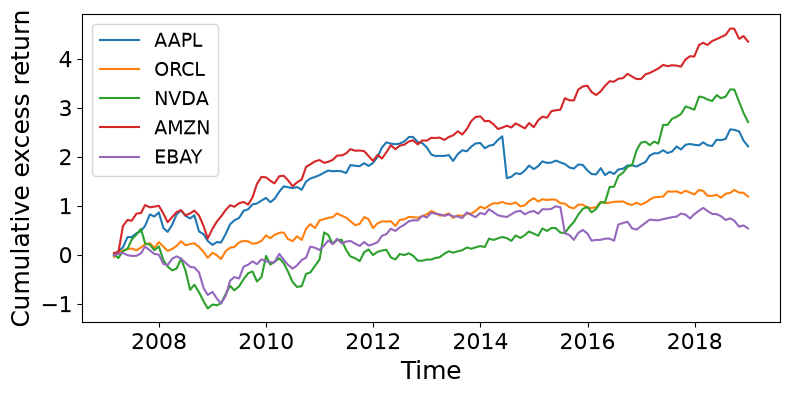

In [15]:
# Calculate the excess return over the risk-free rate for each stock
# The excess return is the return of the stock minus the risk-free rate
crsp['RetRf'] = crsp['RET'] - crsp['rf']

# Create a new figure for plotting with a specified size of 9 inches by 4 inches
plt.figure(figsize=(9, 4))

# Loop through each stock in the list of selected stocks
for stock in lstocks:
    # Filter the data for the current stock and calculate the cumulative sum of the excess returns
    # Plot the cumulative excess return over time
    plt.plot(crsp[crsp.TICKER == stock]['date'].to_numpy(),
             crsp[crsp.TICKER == stock]['RetRf'].cumsum().to_numpy(), label=stock)

# Label the x-axis with "Time" and set the font size to 18
plt.xlabel('Time', fontsize=18)

# Label the y-axis with "Cumulative excess return" and set the font size to 18
plt.ylabel('Cumulative excess return', fontsize=18)

# Add a legend to the plot with the best location and set the font size to 14
plt.legend(loc='best', fontsize=14)

# Set the font size of the x-axis tick labels to 16
plt.xticks(fontsize=16)

# Set the font size of the y-axis tick labels to 16
plt.yticks(fontsize=16)

# Display the plot
plt.show()


Next, let us compute and plotting the Sharpe ratio for each stock in the sample (the expected return, net of the risk-free rate, divided by the volatility):
$$\text{Sharpe}=\frac{\mathbb{E}\text{Return}_i-R_f}{\sigma_i}$$

In [16]:
df_sharpe = crsp[crsp['TICKER'].isin(lstocks)]
df_sharpe = df_sharpe.pivot(columns='TICKER', values='RetRf', index='date')
stat_sharpe = df_sharpe.describe(percentiles=[.1, .25, .5, .75, .9])

In [17]:
stat_sharpe

TICKER,AAPL,AMZN,EBAY,NVDA,ORCL
count,143.000000,143.000000,143.000000,143.000000,143.000000
mean,0.015460,0.030405,0.003745,0.018930,0.008298
std,0.116326,0.101982,0.098616,0.137070,0.065726
min,-0.853191,-0.254318,-0.533201,-0.390389,-0.181818
10%,-0.086671,-0.084872,-0.089637,-0.155294,-0.076605
25%,-0.026334,-0.032141,-0.044908,-0.050347,-0.039261
50%,0.019953,0.026126,0.000000,0.025728,0.010892
75%,0.074182,0.083982,0.057954,0.094252,0.047521
90%,0.128209,0.144048,0.104457,0.157110,0.093578
max,0.234501,0.536942,0.330855,0.553147,0.229014


In [18]:
stat_sharpe = stat_sharpe.loc[['mean', 'std']].T
stat_sharpe

,mean,std
TICKER,,
AAPL,0.015460,0.116326
AMZN,0.030405,0.101982
EBAY,0.003745,0.098616
NVDA,0.018930,0.137070
ORCL,0.008298,0.065726


In [19]:
stat_sharpe['Sharpe']=stat_sharpe['mean']/stat_sharpe['std']
stat_sharpe

,mean,std,Sharpe
TICKER,,,
AAPL,0.015460,0.116326,0.132900
AMZN,0.030405,0.101982,0.298139
EBAY,0.003745,0.098616,0.037978
NVDA,0.018930,0.137070,0.138107
ORCL,0.008298,0.065726,0.126256


Text(0.5, 0, '')

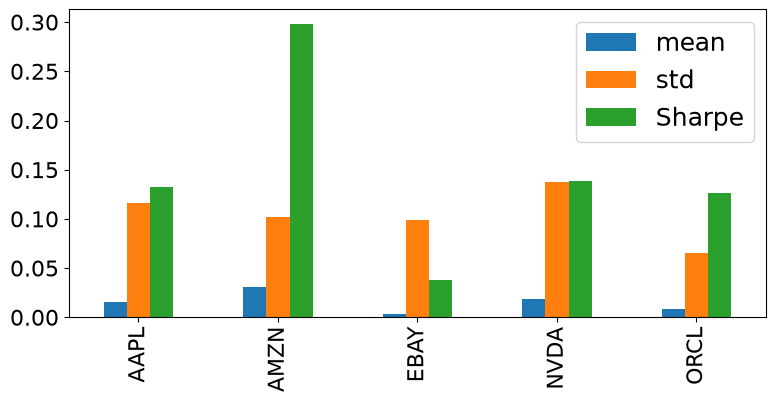

In [20]:
stat_sharpe[['mean', 'std','Sharpe']].plot.bar(figsize=(9, 4))
plt.legend(fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel("")

## Asset pricing models and testing

1. The goal of this exercise is to test: 
    1. the CAPM (only Market matters) 
    2. the 3-factor Fama-French model (Market + SMB + HML factors), and  
    3. the 4-factor Carhart model (Fama-French + Momentum). 

2. To do so, we will run a time-series OLS regression.

3. First, we need form an equally weighted portfolio with our 5 stocks.

4. **Challenge**: Rebalancing. We invest $1 in each stock at the beginning of the period. Simply averaging returns for each stock each month would imply that we rebalance the portfolio each month.

In [21]:
df = crsp[crsp['TICKER'].isin(lstocks)]  # re-load the data

In [22]:
df['TICKER'].drop_duplicates().to_list()

['ORCL', 'AAPL', 'AMZN', 'EBAY', 'NVDA']

### Forming an equally-weighted portfolio

#### Pivot the data so columns are stocks and row are dates. Obtain gross returns by adding 1

In [23]:
df_pivot=df.pivot(columns='TICKER', values='RET', index='date')
df_pivot.head()

TICKER,AAPL,AMZN,EBAY,NVDA,ORCL
date,,,,,
2007-01-31,NaN,NaN,NaN,NaN,NaN
2007-02-28,-0.013064,0.039023,-0.010188,0.011419,-0.042541
2007-03-30,0.098097,0.016607,0.033999,-0.071613,0.103469
2007-04-30,0.074158,0.541342,0.023831,0.142808,0.036955
2007-05-31,0.214339,0.127344,-0.040660,0.053177,0.030851


In [24]:
df_pivot=1+df_pivot # to obtain gross returns
df_pivot.head()

TICKER,AAPL,AMZN,EBAY,NVDA,ORCL
date,,,,,
2007-01-31,NaN,NaN,NaN,NaN,NaN
2007-02-28,0.986936,1.039023,0.989812,1.011419,0.957459
2007-03-30,1.098097,1.016607,1.033999,0.928387,1.103469
2007-04-30,1.074158,1.541342,1.023831,1.142808,1.036955
2007-05-31,1.214339,1.127344,0.959340,1.053177,1.030851


#### Allocate one dollar initially to all of the five stocks

In [25]:
# allocate one dollar to each of the five stocks initially
df_pivot.loc[pd.to_datetime('2007-01-31')]=1 
df_pivot.head()

TICKER,AAPL,AMZN,EBAY,NVDA,ORCL
date,,,,,
2007-01-31,1.000000,1.000000,1.000000,1.000000,1.000000
2007-02-28,0.986936,1.039023,0.989812,1.011419,0.957459
2007-03-30,1.098097,1.016607,1.033999,0.928387,1.103469
2007-04-30,1.074158,1.541342,1.023831,1.142808,1.036955
2007-05-31,1.214339,1.127344,0.959340,1.053177,1.030851


#### Roll over the investment

In [26]:
EW_Invest = df_pivot.cumprod()
EW_Invest.head()

TICKER,AAPL,AMZN,EBAY,NVDA,ORCL
date,,,,,
2007-01-31,1.000000,1.000000,1.000000,1.000000,1.000000
2007-02-28,0.986936,1.039023,0.989812,1.011419,0.957459
2007-03-30,1.083751,1.056278,1.023464,0.938989,1.056527
2007-04-30,1.164120,1.628086,1.047854,1.073083,1.095571
2007-05-31,1.413636,1.835413,1.005249,1.130147,1.129371


#### Computing the value of investment each month (and the return)

In [27]:
EW_Invest['portfolio_value'] = EW_Invest.sum(axis=1)  
EW_Invest.head()

TICKER,AAPL,AMZN,EBAY,NVDA,ORCL,portfolio_value
date,,,,,,
2007-01-31,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000
2007-02-28,0.986936,1.039023,0.989812,1.011419,0.957459,4.984649
2007-03-30,1.083751,1.056278,1.023464,0.938989,1.056527,5.159009
2007-04-30,1.164120,1.628086,1.047854,1.073083,1.095571,6.008714
2007-05-31,1.413636,1.835413,1.005249,1.130147,1.129371,6.513815


In [28]:
EW_Invest['portfolio_return'] = EW_Invest['portfolio_value'].pct_change()  

In [29]:
EW_Invest.head()

TICKER,AAPL,AMZN,EBAY,NVDA,ORCL,portfolio_value,portfolio_return
date,,,,,,,
2007-01-31,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,NaN
2007-02-28,0.986936,1.039023,0.989812,1.011419,0.957459,4.984649,-0.003070
2007-03-30,1.083751,1.056278,1.023464,0.938989,1.056527,5.159009,0.034979
2007-04-30,1.164120,1.628086,1.047854,1.073083,1.095571,6.008714,0.164703
2007-05-31,1.413636,1.835413,1.005249,1.130147,1.129371,6.513815,0.084061


#### Merge the equally weighted data with the factor data

In [30]:
EW_Invest.reset_index()[['date','portfolio_return']]

TICKER,date,portfolio_return
0,2007-01-31,NaN
1,2007-02-28,-0.003070
2,2007-03-30,0.034979
3,2007-04-30,0.164703
4,2007-05-31,0.084061
...,...,...
139,2018-08-31,0.129697
140,2018-09-28,-0.002085
141,2018-10-31,-0.194251
142,2018-11-30,0.008109


In [31]:
test_data=EW_Invest.reset_index()[['date','portfolio_return']].merge(
    crsp[['date','mktrf','smb', 'hml','rf','umd']],on='date',how='left').drop_duplicates().reset_index(drop=True)

In [ ]:
test_data.head()

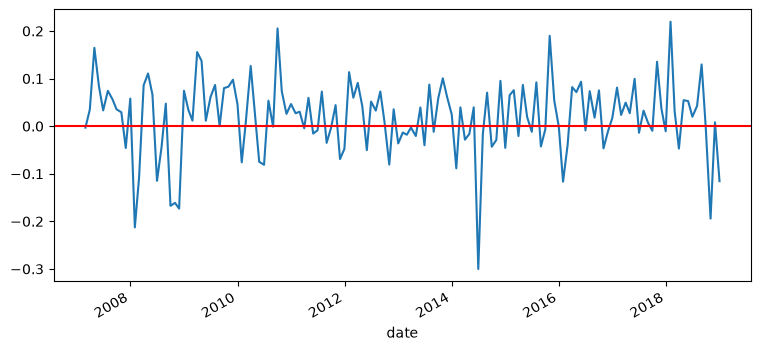

In [32]:
test_data.set_index('date')['portfolio_return'].plot(figsize=(9,4))
plt.axhline(y=0,c='r')

<Axes: xlabel='date'>

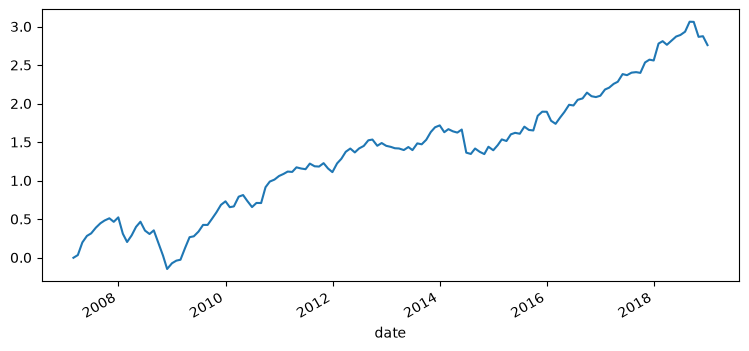

In [33]:
test_data.set_index('date')['portfolio_return'].cumsum().plot(figsize=(9,4))

### Factor model estimation

We want to estimate the following factor model

$$R_{t}-RF_t = \alpha + \beta_0 \left(R_{M,t}-RF_t\right)+ \beta_1 \text{SMB}+ \beta_2 \text{HML} + \beta_3  \text{UMD} + \varepsilon_t.$$ 


In [34]:
import statsmodels.formula.api as smf # load the econometrics package

In [35]:
test_data['ExcessReturn']=test_data['portfolio_return']-test_data['rf']
test_data=test_data.dropna()

In [36]:
test_data

,date,portfolio_return,mktrf,smb,hml,rf,umd,ExcessReturn
1,2007-02-28,-0.003070,-0.0196,0.0132,-0.0009,0.0038,-0.0135,-0.006870
2,2007-03-30,0.034979,0.0068,-0.0006,-0.0022,0.0043,0.0247,0.030679
3,2007-04-30,0.164703,0.0349,-0.0206,-0.0115,0.0044,-0.0016,0.160303
4,2007-05-31,0.084061,0.0324,0.0003,-0.0005,0.0041,-0.0026,0.079961
5,2007-06-29,0.033110,-0.0196,0.0077,-0.0113,0.0040,0.0038,0.029110
...,...,...,...,...,...,...,...,...
139,2018-08-31,0.129697,0.0344,0.0123,-0.0412,0.0016,0.0530,0.128097
140,2018-09-28,-0.002085,0.0006,-0.0237,-0.0134,0.0015,-0.0009,-0.003585
141,2018-10-31,-0.194251,-0.0768,-0.0468,0.0341,0.0019,-0.0182,-0.196151
142,2018-11-30,0.008109,0.0169,-0.0074,0.0019,0.0018,-0.0140,0.006309


#### CAPM Model. What do you infer?

We first estimate the CAPM model, where the only factor is the (excess) market return.

In [37]:
reg_CAPM = smf.ols(data=test_data, formula='ExcessReturn~mktrf').fit(cov_type='HC3')
reg_CAPM.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           ExcessReturn   R-squared:                       0.431
Model:                            OLS   Adj. R-squared:                  0.427
Method:                 Least Squares   F-statistic:                     78.65
Date:                Mon, 17 Aug 2026   Prob (F-statistic):           2.96e-15
Time:                        12:25:56   Log-Likelihood:                 202.91
No. Observations:                 143   AIC:                            -401.8
Df Residuals:                     141   BIC:                            -395.9
Df Model:                           1                                         
Covariance Type:                  HC3                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0114      0.005      2.238      0.025       0.001       0.021
mktrf          1.1692      0.132      8.869      0.000       0.911       1.428
==============================================================================
Omnibus:                       56.520   Durbin-Watson:                   1.775
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              328.308
Skew:                          -1.243   Prob(JB):                     5.12e-72
Kurtosis:                       9.994   Cond. No.                         22.9
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

In [38]:
hypotheses='mktrf=1'
reg_CAPM.t_test(hypotheses)

<class 'statsmodels.stats.contrast.ContrastResults'>
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             1.1692      0.132      1.283      0.199       0.911       1.428

#### 3-Factor Model. What do you infer?

Next, we turn to the Fama-French three factor model, including the market return, the small-minus-big and the high-minus-low portfolios.

In [41]:
reg_FF3 = smf.ols(data=test_data, formula='ExcessReturn~mktrf+smb+hml').fit(cov_type='HC3')
reg_FF3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           ExcessReturn   R-squared:                       0.537
Model:                            OLS   Adj. R-squared:                  0.527
Method:                 Least Squares   F-statistic:                     50.07
Date:                Mon, 17 Aug 2026   Prob (F-statistic):           5.27e-22
Time:                        12:26:19   Log-Likelihood:                 217.60
No. Observations:                 143   AIC:                            -427.2
Df Residuals:                     139   BIC:                            -415.4
Df Model:                           3                                         
Covariance Type:                  HC3                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0082      0.004      1.833      0.067      -0.001       0.017
mktrf          1.3854      0.119     11.671      0.000       1.153       1.618
smb           -0.3222      0.222     -1.454      0.146      -0.756       0.112
hml           -0.9298      0.163     -5.707      0.000      -1.249      -0.610
==============================================================================
Omnibus:                       86.460   Durbin-Watson:                   1.778
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              781.769
Skew:                          -1.936   Prob(JB):                    1.74e-170
Kurtosis:                      13.780   Cond. No.                         47.2
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

We test whether our portfolio has a $\beta$ larger than one. How do you interpret the result?

In [42]:
hypotheses='mktrf=1'
reg_FF3.t_test(hypotheses)

<class 'statsmodels.stats.contrast.ContrastResults'>
                             Test for Constraints                             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c0             1.3854      0.119      3.247      0.001       1.153       1.618

#### 4-Factor (Fama-French + Momentum Model). What do you infer? 

Finally, we estimate the Carhart four factor model, including the market return, the small-minus-big and the high-minus-low portfolios, as well as the momentum (up-minus-down) factor.

In [43]:
reg_Carhart = smf.ols(data=test_data, formula='ExcessReturn~mktrf+smb+hml+umd').fit(cov_type='HC3')
reg_Carhart.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           ExcessReturn   R-squared:                       0.538
Model:                            OLS   Adj. R-squared:                  0.524
Method:                 Least Squares   F-statistic:                     37.69
Date:                Mon, 17 Aug 2026   Prob (F-statistic):           2.77e-21
Time:                        12:26:50   Log-Likelihood:                 217.78
No. Observations:                 143   AIC:                            -425.6
Df Residuals:                     138   BIC:                            -410.8
Df Model:                           4                                         
Covariance Type:                  HC3                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0083      0.005      1.829      0.067      -0.001       0.017
mktrf          1.3690      0.127     10.821      0.000       1.121       1.617
smb           -0.3211      0.223     -1.437      0.151      -0.759       0.117
hml           -0.9751      0.163     -5.970      0.000      -1.295      -0.655
umd           -0.0657      0.118     -0.559      0.576      -0.296       0.165
==============================================================================
Omnibus:                       86.881   Durbin-Watson:                   1.780
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              786.926
Skew:                          -1.949   Prob(JB):                    1.32e-171
Kurtosis:                      13.811   Cond. No.                         47.6
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

## Time-varying parameters: Rolling-window estimation of $\alpha$ and $\beta$

Model coefficients may change over time. Let us fix a 60 month rolling estimation period and track changes in $\alpha$ and $\beta$ over the entire sample.

In [44]:
n_obs=test_data.count()['date']
n_obs

np.int64(143)

In [45]:
n_obs=test_data.count()['date'] # number of observations in the data
rolling_window_size=60 # size of the rolling window

alphas=[]
betas=[]

for k in range(n_obs-rolling_window_size):
    
    temp_reg=smf.ols(data=test_data[k:rolling_window_size+k+1], 
                     formula='ExcessReturn~mktrf').fit(cov_type='HC3')
    alphas.append(temp_reg.params['Intercept'])
    betas.append(temp_reg.params['mktrf'])
    print(k, temp_reg.params['Intercept'], temp_reg.params['mktrf'])

0 0.01783323701900115 1.101450154508673
1 0.01850642569848401 1.106927575453761
2 0.018976841614575607 1.104875871252168
3 0.017294659746131813 1.0869488902858828
4 0.016722018131747098 1.0809047248078252
5 0.01628689733952554 1.0848696805977094
6 0.01515103672053732 1.1081777818267904
7 0.014132988325613561 1.1026935311509116
8 0.013157296151715212 1.113254472513133
9 0.013493588376531798 1.1142787349075034
10 0.012623242349820644 1.1088485386718263
11 0.010407244979690016 1.0884167242340594
12 0.012580273616958192 1.0287699547648752
13 0.013293522563092516 1.0003535661573995
14 0.011136141010370026 1.0049900938297938
15 0.010362835155381452 0.9939191130264067
16 0.009134604277750608 0.9952178092933248
17 0.01031073752887981 0.9795021971427935
18 0.01122288562124176 0.9743769835058507
19 0.01106651738237161 0.9753721421580288
20 0.013812920737730673 0.9301647987218808
21 0.014638088488650957 0.9114202522732058
22 0.01764832628595919 0.824464781620174
23 0.015244552465509445 0.85252432

In [46]:
len(betas)

83

In [47]:
coefficients=pd.DataFrame(columns=['alpha','beta'])
coefficients['alpha']=alphas
coefficients['beta']=betas
coefficients['date']=test_data[rolling_window_size:].reset_index()['date']
coefficients.head()

,alpha,beta,date
0,0.017833,1.101450,2012-02-29
1,0.018506,1.106928,2012-03-30
2,0.018977,1.104876,2012-04-30
3,0.017295,1.086949,2012-05-31
4,0.016722,1.080905,2012-06-29


<Axes: xlabel='date'>

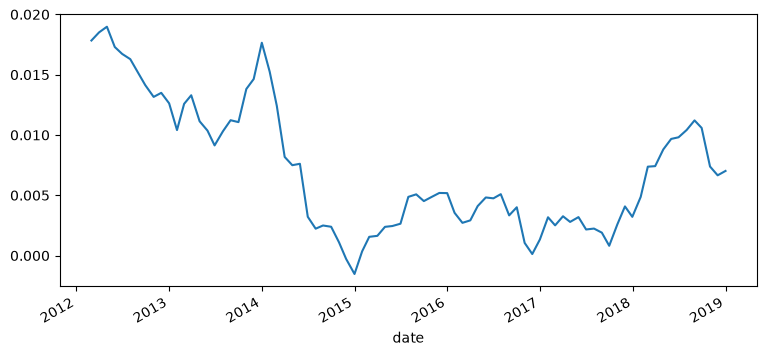

In [48]:
coefficients.set_index('date')['alpha'].plot(figsize=(9,4))

<Axes: xlabel='date'>

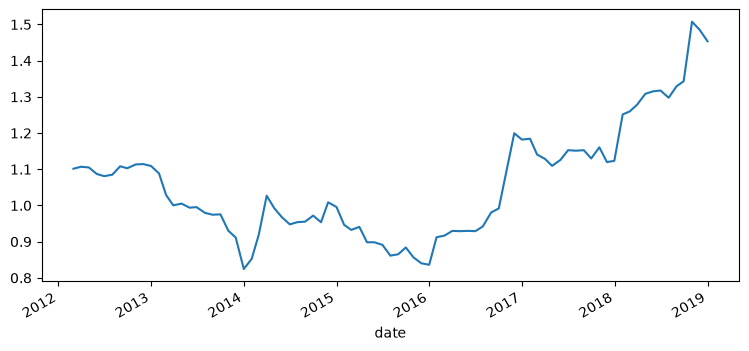

In [49]:
coefficients.set_index('date')['beta'].plot(figsize=(9,4))

In [50]:
n_obs=test_data.count()['date'] # number of observations in the data
rolling_window_size=60 # size of the rolling window

alphas_M=[]
alphas_FF=[]
alphas_C=[]

for k in range(n_obs-rolling_window_size):

    temp_M=smf.ols(data=test_data[k:rolling_window_size+k+1], formula='ExcessReturn~mktrf').fit(cov_type='HC2')
    temp_FF=smf.ols(data=test_data[k:rolling_window_size+k+1], formula='ExcessReturn~mktrf+hml+smb').fit(cov_type='HC2')
    temp_C=smf.ols(data=test_data[k:rolling_window_size+k+1], formula='ExcessReturn~mktrf+hml+smb+umd').fit(cov_type='HC2')
   
    alphas_M.append(temp_M.params['Intercept'])
    alphas_FF.append(temp_FF.params['Intercept'])
    alphas_C.append(temp_C.params['Intercept'])

In [51]:
alphas=pd.DataFrame(columns=['M','FF','C'])
alphas['M']=alphas_M
alphas['FF']=alphas_FF
alphas['C']=alphas_C
alphas['date']=test_data[rolling_window_size:].reset_index()['date']
alphas.head()

,M,FF,C,date
0,0.017833,0.012895,0.012244,2012-02-29
1,0.018506,0.013619,0.013119,2012-03-30
2,0.018977,0.014133,0.013680,2012-04-30
3,0.017295,0.012778,0.012391,2012-05-31
4,0.016722,0.012231,0.011830,2012-06-29


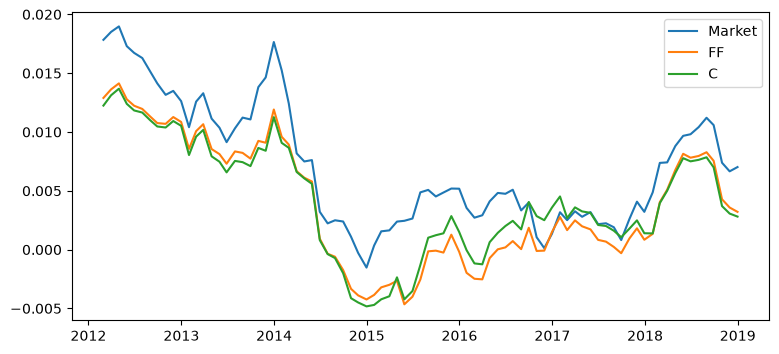

In [52]:
plt.figure(figsize=(9,4))
plt.plot(alphas['date'].to_numpy(),alphas['M'].to_numpy(),label='Market')
plt.plot(alphas['date'].to_numpy(),alphas['FF'].to_numpy(),label='FF')
plt.plot(alphas['date'].to_numpy(),alphas['C'].to_numpy(),label='C')
plt.legend(loc='best')

What do you infer? What is the relationship between model-implied $\alpha$s as we add more factors?